<h1>3.5 DSSD front-back 关联：strip normalization</h1><p>3.4 用单个 pixel 建立两条间的对应关系。如果某些 pixel 事例很少，可以把已在共同尺度上的多条作为参考，集中统计量刻度另一面。本节保留三步传播：X[16] → Y[8–16] → 全部 X → 全部 Y。</p><p>参考条固定 <code>b=0,k=1</code>，其他条的系数相对于它确定。这样得到的是同一探测器内可比较的相对幅度，不是绝对能量。覆盖范围取决于实际有数据连接的条；没有可用数据的条不应被默认视为已刻度。</p>

In [ ]:
#include <iostream>
#include <fstream>
#include <cmath>

#include "TFile.h"
#include "TTree.h"
#include "TCanvas.h"
#include "TROOT.h"
#include "TStyle.h"
#include "TGraph.h"
#include "TF1.h"
#include "TH1F.h"
#include "TH2F.h"
#include "TRandom.h"
#include "TMath.h"
#include "TString.h"

using namespace std;

// ---------- notebook-global objects ----------
TFile   *fin  = nullptr;
TTree   *tree = nullptr;
TCanvas *c1   = nullptr;

Int_t ix, iy;
Int_t xe, ye;

double parx[32][2], pary[32][2];

// Residual objects kept in memory for direct display
TH2F   *gResiduals[32] = {nullptr};
TCanvas *gResidualCanvas = nullptr;

In [ ]:
%%cpp -d
    
void DeleteIfExists(const char* name) {
    TObject *obj = gROOT->FindObject(name);
    if (obj) delete obj;
}

void ClearResiduals() {
    for (int i = 0; i < 32; ++i) {
        if (gResiduals[i]) {
            delete gResiduals[i];
            gResiduals[i] = nullptr;
        }
    }
}

void InitPars() {
    for (int i = 0; i < 32; ++i) {
        parx[i][0] = 0.0; parx[i][1] = 0.0;   // k=0 表示尚未刻度
        pary[i][0] = 0.0; pary[i][1] = 0.0;   // b_y, k_y
    }
    parx[16][1] = 1.0; // 唯一参考尺度
}

inline double Ex(int ix, double xe) {
    return parx[ix][1] * xe + parx[ix][0];
}

inline double Ey(int iy, double ye) {
    return pary[iy][1] * ye + pary[iy][0];
}


void DrawResiduals(int id1, int id2, const char* cname = "c_residuals")
{
    if (!gResidualCanvas) {
        gResidualCanvas = new TCanvas(cname, cname, 1000, 1400);
    } else {
        gResidualCanvas->SetName(cname);
        gResidualCanvas->SetTitle(cname);
        gResidualCanvas->Clear();
    }

    gResidualCanvas->Divide(4, 8);

    for (int id = id1; id <= id2; ++id) {
        if (!gResiduals[id]) continue;
        gResidualCanvas->cd(id + 1);
        gResiduals[id]->Draw("colz");
    }

    gResidualCanvas->Update();
}

<h2>输入与参数表</h2><p><code>data/d1xy.root</code> 保存前一节方法得到的候选：<code>ix,iy</code> 是条号，<code>xe,ye</code> 是两条的 raw amplitude。选择降低了可见 sharing 和远离条带的组合，但样本仍需 residual 检查。</p>

In [5]:
DeleteIfExists("c1");
c1 = new TCanvas("c1", "c1", 900, 700);

fin = new TFile("./data/d1xy.root");
tree = (TTree*)fin->Get("tree");

tree->SetBranchAddress("ix", &ix);
tree->SetBranchAddress("iy", &iy);
tree->SetBranchAddress("xe", &xe);
tree->SetBranchAddress("ye", &ye);

InitPars();
gRandom->SetSeed(20260418);

cout << "Entries = " << tree->GetEntries() << endl;

Entries = 210820

<h3>先检查整体关联</h3><p>查看所有候选的 x-y 主条带和离群区域。这一步判断是否有可用的线性关联，不直接给出每条的刻度，也不能证明每个候选都正确。</p>

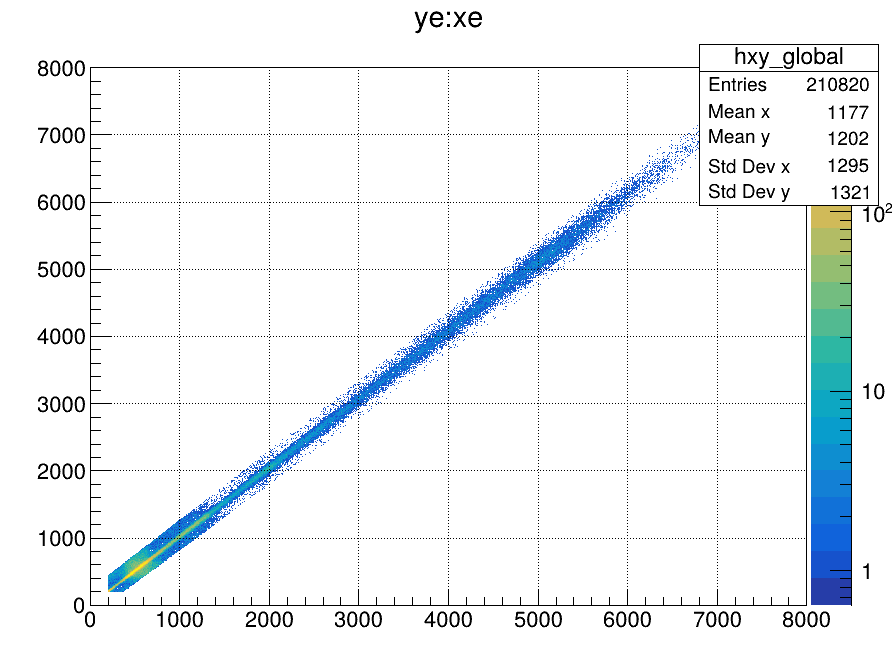

In [7]:
DeleteIfExists("hxy_global");
tree->Draw("ye:xe>>hxy_global(1000,0,8000,1000,0,8000)", "", "colz");
c1->SetLogz();
c1->SetGrid(1,1);
c1->Draw();

<h3>选择起始参考条</h3><p>统计各条的候选数。本例 X[16] 的统计量较好，并与 Y[8–16] 有较多交叉事例，因而采用这一区域开始传播。除了数量，也应查看幅度覆盖范围和 residual。</p>

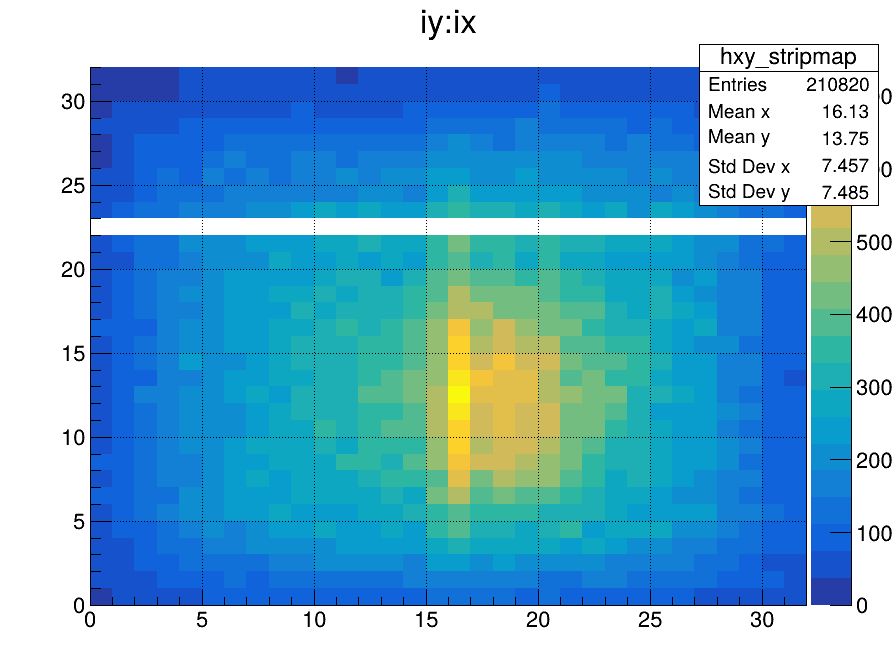

In [9]:
DeleteIfExists("hxy_stripmap");
tree->Draw("iy:ix>>hxy_stripmap(32,0,32,32,0,32)", "", "colz");
c1->SetLogz(0);
c1->Draw();

Highest x-strip bin = 16
Highest y-strip bin = 12

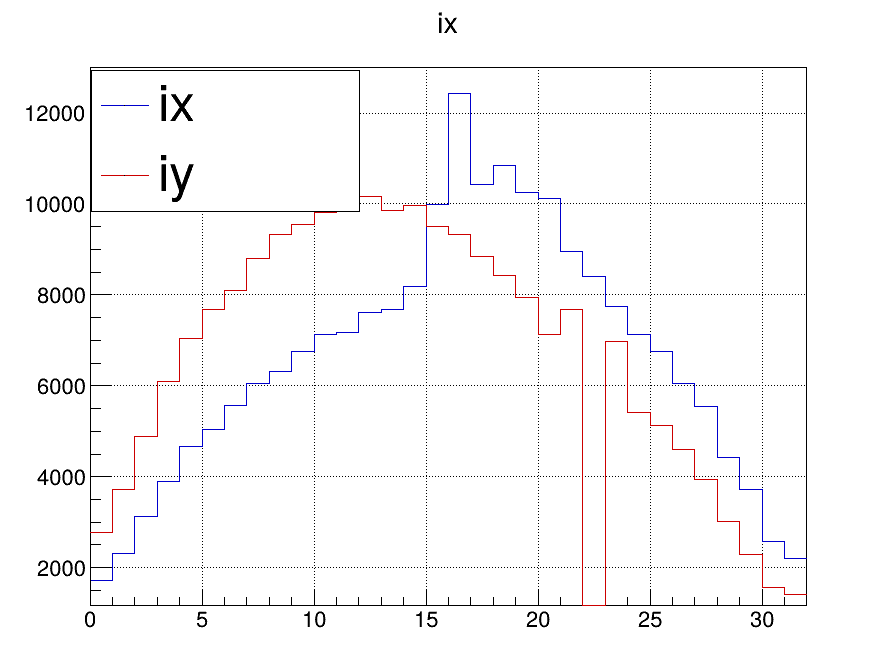

In [10]:
DeleteIfExists("hx");
DeleteIfExists("hy");

tree->Draw("ix>>hx(32,0,32)", "", "goff");
tree->Draw("iy>>hy(32,0,32)", "", "goff");

auto hx = (TH1F*)gROOT->FindObject("hx");
auto hy = (TH1F*)gROOT->FindObject("hy");

DeleteIfExists("c_strip_counts");
auto c_strip_counts = new TCanvas("c_strip_counts", "Strip counts", 900, 700);
hx->SetLineColor(kBlue+1);
hy->SetLineColor(kRed+1);
hx->SetStats(0);
hy->SetStats(0);
hx->Draw("hist");
hy->Draw("hist same");
c_strip_counts->BuildLegend();
c_strip_counts->SetGrid(1,1);
c_strip_counts->Draw();

cout << "Highest x-strip bin = " << hx->GetMaximumBin() - 1 << endl;
cout << "Highest y-strip bin = " << hy->GetMaximumBin() - 1 << endl;

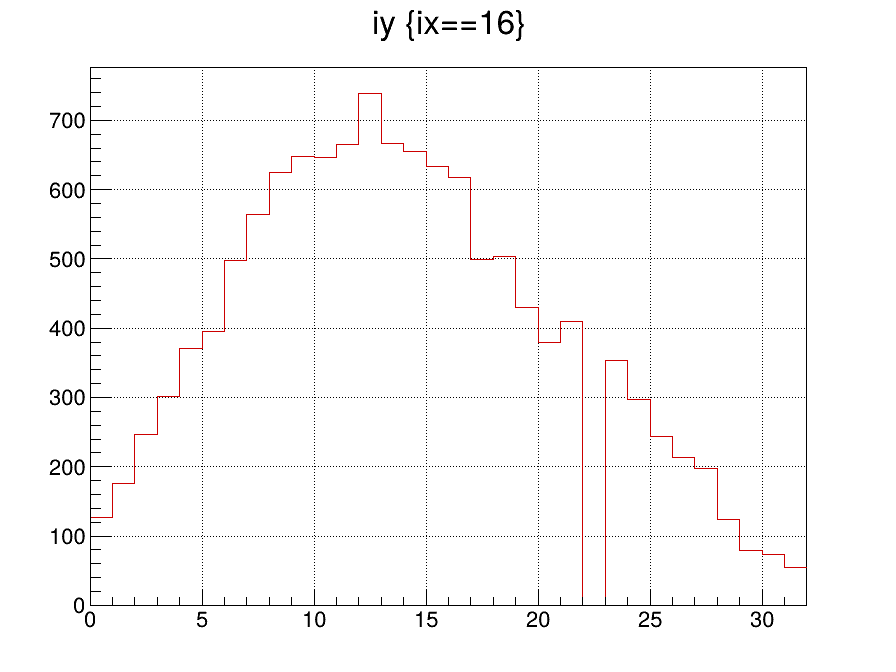

In [11]:
DeleteIfExists("hy_ix16");
tree->Draw("iy>>hy_ix16(32,0,32)", "ix==16", "hist");

DeleteIfExists("c_ix16");
auto c_ix16 = new TCanvas("c_ix16", "iy distribution under ix==16", 900, 700);
auto hy_ix16 = (TH1F*)gROOT->FindObject("hy_ix16");
hy_ix16->SetStats(0);
hy_ix16->SetLineColor(kRed+1);
hy_ix16->Draw("hist");
c_ix16->SetGrid(1,1);
c_ix16->Draw();

<p>以下固定 X[16] 为参考，第一步刻度 Y[8–16]。</p>

<h3>拟合区间内的事例分布</h3><p>低幅度区的事例较多。若直线模型及误差假设成立，这本身不会使拟合有偏，也不是随机丢弃该区间事例的理由。下面保留全部通过物理选择的事例，用各条的 residual 检查整个幅度范围。</p>

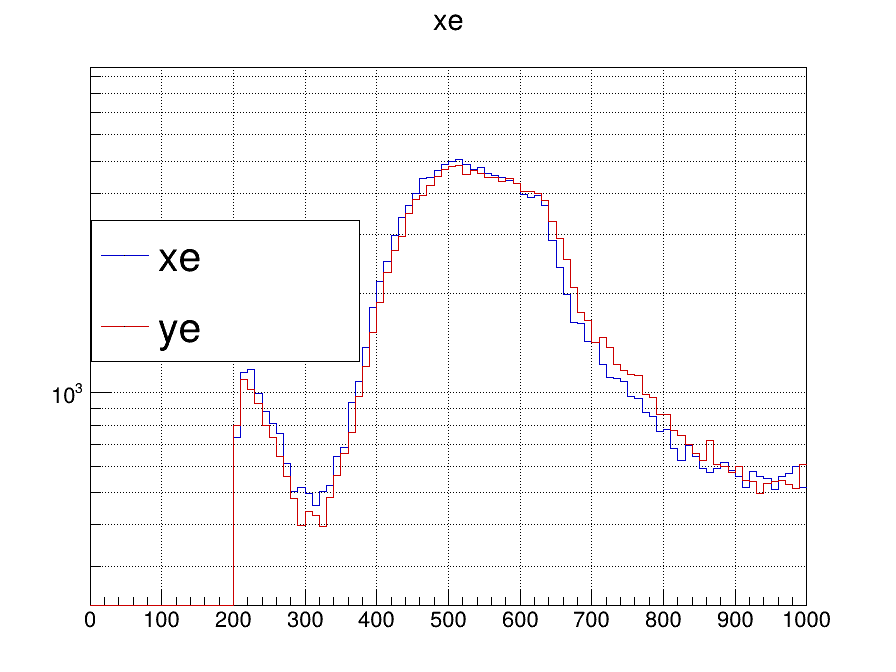

In [14]:
DeleteIfExists("hxe");
DeleteIfExists("hye");

tree->Draw("xe>>hxe(100,0,1000)", "", "goff");
tree->Draw("ye>>hye(100,0,1000)", "", "goff");

auto hxe = (TH1F*)gROOT->FindObject("hxe");
auto hye = (TH1F*)gROOT->FindObject("hye");

DeleteIfExists("c_amp");
auto c_amp = new TCanvas("c_amp", "Amplitude spectra", 900, 700);
hxe->SetStats(0);
hye->SetStats(0);
hxe->SetLineColor(kBlue+1);
hye->SetLineColor(kRed+1);
hxe->Draw("hist");
hye->Draw("hist same");
c_amp->SetLogy();
c_amp->SetGrid(1,1);
c_amp->BuildLegend();
c_amp->Draw();

<h2>先看一条 Y 如何得到 b、k</h2>
<p>以 Y[12] 为例，选择 <code>ix==16 &amp;&amp; iy==12</code>。横轴是待刻度 Y 的 raw amplitude，纵轴是已刻度 X 的参考幅度；初始参考 X[16] 的幅度就是 <code>xe</code>。因此 <code>pol1</code> 的截距、斜率可直接用于 $E_y^{(\rm rel)}=b_y+k_y A_y$，不要把两轴放反后仍使用同一组系数。</p>

Y[12]: b=12.6699, k=1.0001, N=739

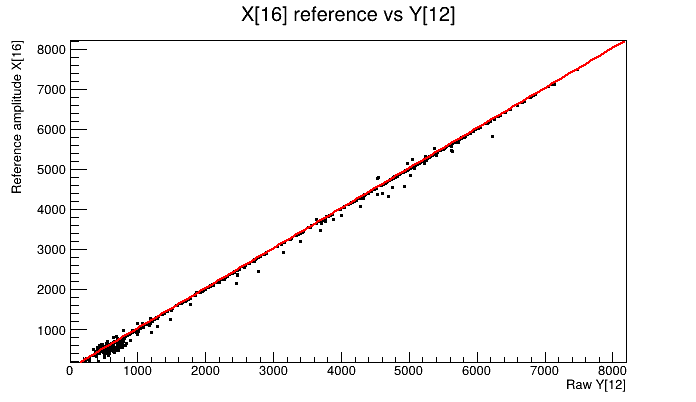

In [16]:
tree->SetEstimate(tree->GetEntries()+1);
tree->Draw("xe:ye","ix==16 && iy==12","goff");
TGraph *gExample=new TGraph(tree->GetSelectedRows(),tree->GetV2(),tree->GetV1());
TCanvas *cStripExample=new TCanvas("cStripExample","One-strip normalization",700,430);
gExample->SetTitle("X[16] reference vs Y[12];Raw Y[12];Reference amplitude X[16]");
gExample->SetMarkerStyle(7);
gExample->Draw("AP");
gExample->Fit("pol1","Q ROB");
TF1 *fExample=gExample->GetFunction("pol1");
cout << "Y[12]: b=" << fExample->GetParameter(0) << ", k=" << fExample->GetParameter(1)
     << ", N=" << gExample->GetN() << endl;
cStripExample->Draw();

<h3>对多条重复相同操作</h3><p><code>parx[i][0/1]</code>、<code>pary[j][0/1]</code> 分别保存 <strong>b、k</strong>。<code>Ex</code>、<code>Ey</code> 按这两张表转换幅度。下面把例行操作分为收集关联点、拟合、画 residual 三部分。</p><p><code>fity</code> 使用已刻度 X 面作纵轴参考，求 Y 系数；<code>fitx</code> 则相反。无逐点误差的 TGraph 拟合输出 RSS/NDF 带有幅度平方单位，不能要求它接近 1 来评价拟合。</p>

In [ ]:
%%cpp -d
TGraph *g[32];
Int_t npt[32];
void collectCorrelations(Int_t ix1, Int_t ix2, Int_t iy1, Int_t iy2, TString fitmethod)
{
    Int_t id1 = (fitmethod == "fity") ? iy1 : ix1;
    Int_t id2 = (fitmethod == "fity") ? iy2 : ix2;
    TString sid = (fitmethod == "fity") ? "iy" : "ix";



    for (Int_t i = 0; i < 32; ++i) {
        g[i] = new TGraph();
        npt[i] = 0;
    }

    ClearResiduals();

    Long64_t nentries = tree->GetEntries();
    for (Long64_t jentry = 0; jentry < nentries; ++jentry) {
        tree->GetEntry(jentry);

        if (ix < ix1 || ix > ix2 || iy < iy1 || iy > iy2) continue;

        if (fitmethod == "fity") {
            if (parx[ix][1] <= 0) continue;
            double Eref = Ex(ix, xe);
            double target_raw = ye;
            g[iy]->SetPoint(npt[iy]++, target_raw, Eref);
        } else if (fitmethod == "fitx") {
            if (pary[iy][1] <= 0) continue;
            double Eref = Ey(iy, ye);
            double target_raw = xe;
            g[ix]->SetPoint(npt[ix]++, target_raw, Eref);
        } else {
            cout << "Unknown fitmethod: " << fitmethod << endl;
            for (Int_t i = 0; i < 32; ++i) delete g[i];
            return;
        }
    }

}

<h3>拟合各条并更新系数</h3><p>只拟合至少有 20 个候选点的条，这是本例的最低数量检查，不保证幅度范围或拟合质量。参考 X[16] 始终保持 b=0、k=1，避免改变尺度定义。</p>

In [ ]:
%%cpp -d
void fitCorrelations(Int_t id1, Int_t id2, TString fitmethod) {
    TString sid = fitmethod=="fity" ? "iy":"ix";
    cout << Form("%4s%12s%12s%12s%10s",
                 sid.Data(), "b", "k", "RSS/NDF", "Ncounts") << endl;

    for (Int_t id = id1; id <= id2; ++id) {
        if (npt[id] < 20) {
            printf("Warning: too few points for %s-strip %d\n", sid.Data(), id);
            continue;
        }

        int status = g[id]->Fit("pol1", "Q ROB");
        if (status != 0) throw std::runtime_error("strip fit failed");
        TF1 *f = g[id]->GetFunction("pol1");
        if (!f) continue;

        double b = f->GetParameter(0);
        double k = f->GetParameter(1);
        double c2n = (f->GetNDF() > 0) ? f->GetChisquare() / f->GetNDF() : 0.0;

        if (fitmethod == "fity") {
            pary[id][0] = b;
            pary[id][1] = k;
        } else {
            if (id == 16) { b = 0; k = 1; } // 固定参考条定义
            parx[id][0] = b;
            parx[id][1] = k;
        }

        cout << Form("%4d%12.3f%12.6f%12.2f%10d",
                     id, b, k, c2n, npt[id]) << endl;
    }

}

<h3>查看 residual</h3><p>每个点计算“参考幅度 − 新刻度幅度”，在各条的图中检查是否有随幅度变化的弯曲或偏移。绘图使用拟合过的同一批点，属于一致性检查；独立 run 可用于进一步验证。</p>

In [ ]:
%%cpp -d

void showResiduals(Int_t id1, Int_t id2, TString fitmethod) {
    TString sid=fitmethod=="fity" ? "iy":"ix";
    for(int id=id1;id<=id2;++id) {
        double b=fitmethod=="fity"?pary[id][0]:parx[id][0];
        double k=fitmethod=="fity"?pary[id][1]:parx[id][1];
        if(k<=0 || g[id]->GetN()<20) continue;
        gResiduals[id] = new TH2F(
            Form("h2res_%s_%02d", sid.Data(), id),
            Form("Residuals %s-strip %d;Residual;Raw amplitude", sid.Data(), id),
            100, -50, 50,
            800, 0, 8000
        );

        double *x = g[id]->GetX();
        double *y = g[id]->GetY();
        for (Int_t i = 0; i < g[id]->GetN(); ++i) {
            double r = y[i] - (b + k * x[i]);
            gResiduals[id]->Fill(r, x[i]);
        }


    }
    DrawResiduals(id1,id2,Form("c_res_%s",fitmethod.Data()));
    for(int i=0;i<32;++i) delete g[i];
}
void fit(Int_t ix1,Int_t ix2,Int_t iy1,Int_t iy2,TString method) {
    int first=method=="fity"?iy1:ix1, last=method=="fity"?iy2:ix2;
    collectCorrelations(ix1,ix2,iy1,iy2,method);
    fitCorrelations(first,last,method);
    showResiduals(first,last,method);
}

<p>现在三个调用按同一顺序收集、拟合并显示结果，物理选择与前面的单条例子相同。</p>

<h2>三步刻度</h2><h3>1. X[16] → Y[8–16]</h3><p>用初始参考条建立中央 Y 区域的共同尺度。</p>

iy           b           k     RSS/NDF   Ncounts
   8       8.848    0.992463     3159.68       624
   9      11.621    0.963428     2927.41       648
  10      12.113    0.988140     3023.87       646
  11      15.446    0.981926     4096.16       665
  12      12.670    1.000101     4710.16       739
  13      15.391    0.979973     3372.09       667
  14       8.540    0.980518     2807.11       655
  15      18.120    0.988528     3485.80       634
  16      -3.045    0.980788     2663.90       618

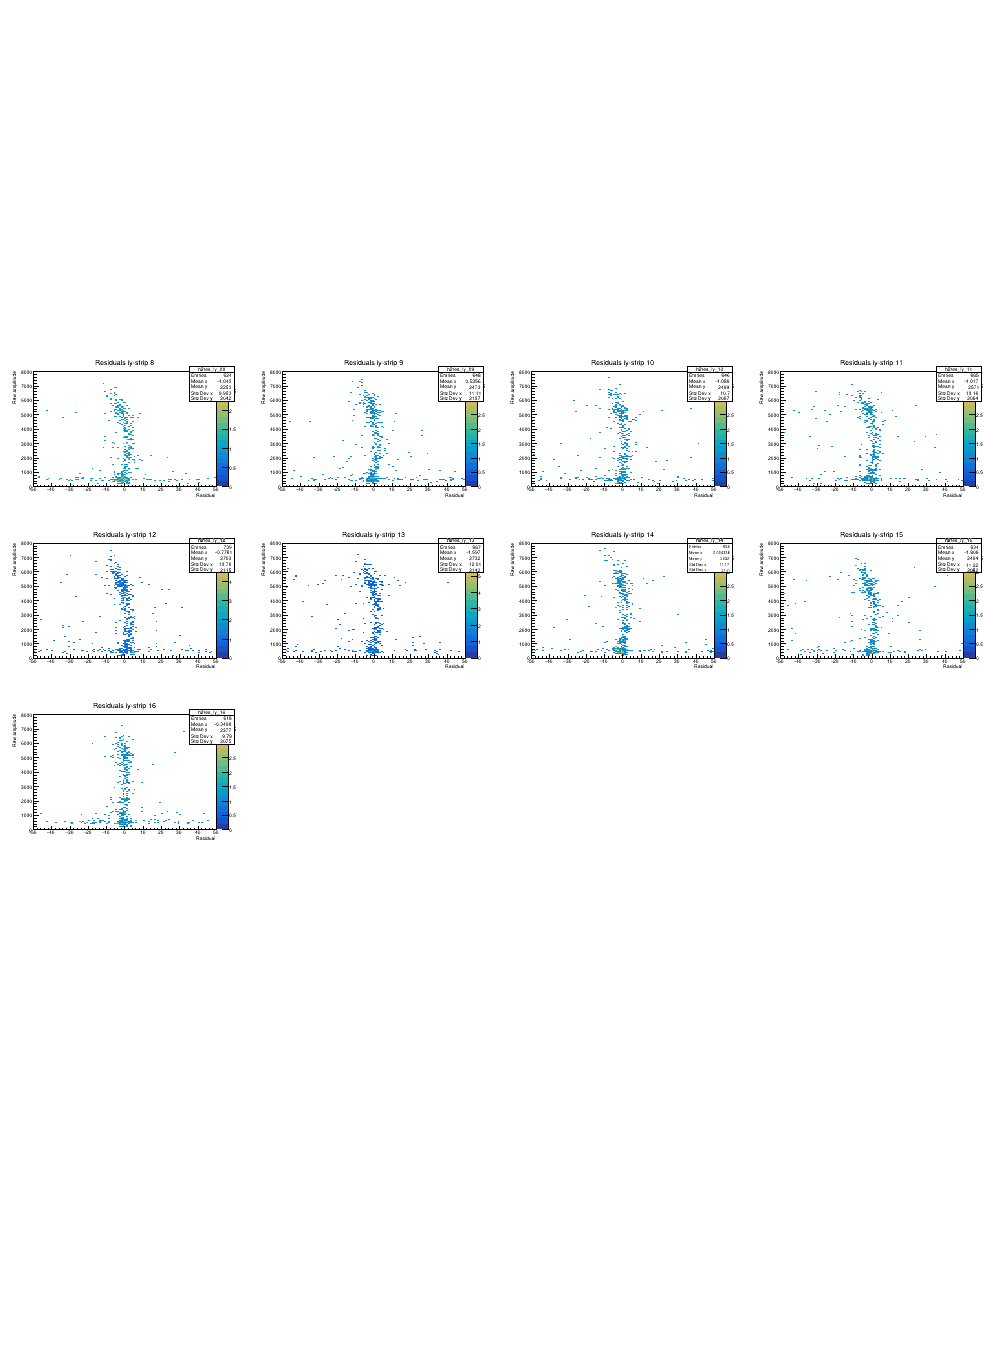

In [25]:
fit(16,16,8,16,"fity");
gResidualCanvas->Draw();

<h3>2. Y[8–16] → 全部 X</h3><p>合并已经刻度的 Y 条，增加每条 X 的统计量。X[16] 不改变。</p>

ix           b           k     RSS/NDF   Ncounts
   0      10.389    1.000933     6716.36       655
   1       4.299    1.008209     4903.25       857
   2      -0.385    1.009543     4728.56      1148
   3       4.924    0.991829     4406.25      1491
   4      -0.093    1.001333     3991.13      1794
   5       5.364    1.019099     3608.47      1871
   6       1.127    1.014107     3624.36      2072
   7       5.090    1.011215     3715.73      2299
   8       0.458    1.008845     3587.61      2470
   9       6.281    1.006272     3936.94      2629
  10       2.460    1.022629     3739.39      2852
  11       6.124    1.016585     3762.37      2904
  12       1.769    0.995693     4152.10      3151
  13       6.390    1.021075     4083.65      3229
  14      -0.394    1.027882     3766.84      3540
  15       8.819    1.002739     4028.71      4288
  16       0.000    1.000000     3378.00      5896
  17       6.594    1.006122     3569.47      4804
  18      -0.614    1.014386     

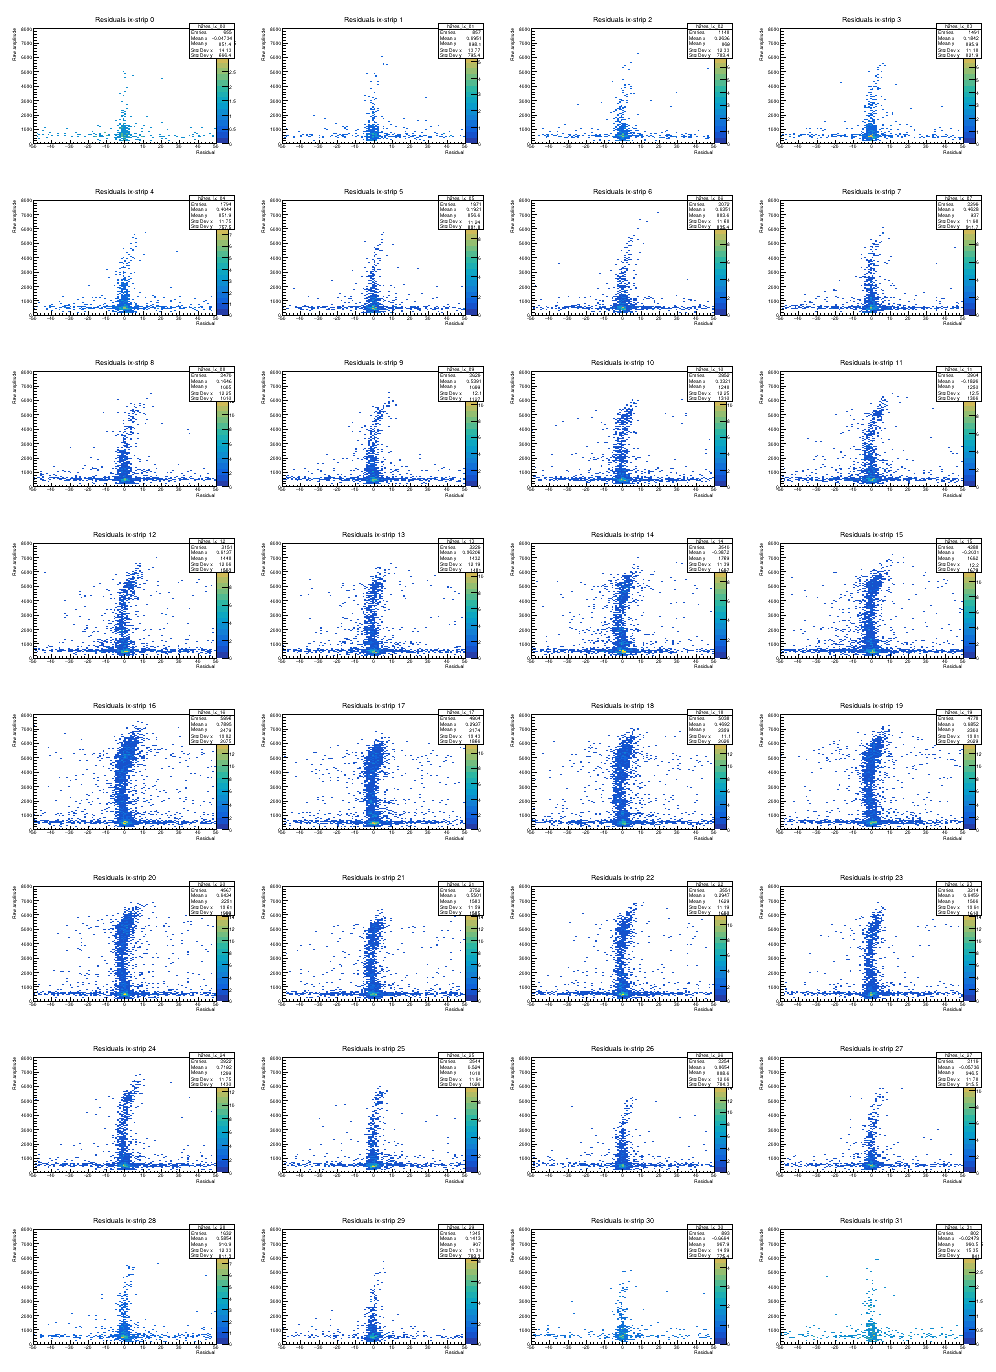

In [27]:
fit(0,31,8,16,"fitx");
gResidualCanvas->Draw();

<h3>3. 全部已刻度 X → 全部 Y</h3><p>再用有可用系数的 X 条完成其余 Y 条。</p>

iy           b           k     RSS/NDF   Ncounts
   0      22.707    0.955995     4963.03      2766
   1      16.217    0.975460     4422.75      3724
   2      15.663    0.971192     3723.34      4885
   3      20.765    0.975613     3984.99      6100
   4       7.876    0.978102     3506.12      7052
   5      15.405    0.986436     3768.78      7684
   6       9.777    0.982499     3507.63      8103
   7      19.316    0.992218     3836.83      8796
   8       8.694    0.992539     3600.32      9329
   9      11.626    0.963469     3588.51      9544
  10      12.020    0.988186     3901.94      9822
  11      15.292    0.981885     3871.81      9826
  12      13.265    0.999913     4096.17     10172
  13      15.414    0.980002     3532.44      9859
  14       8.314    0.980586     3595.56      9976
  15      18.226    0.988434     3939.62      9502
  16      -3.209    0.980775     3518.77      9331
  17      11.237    0.969825     3461.55      8834
  18       0.506    1.000730     

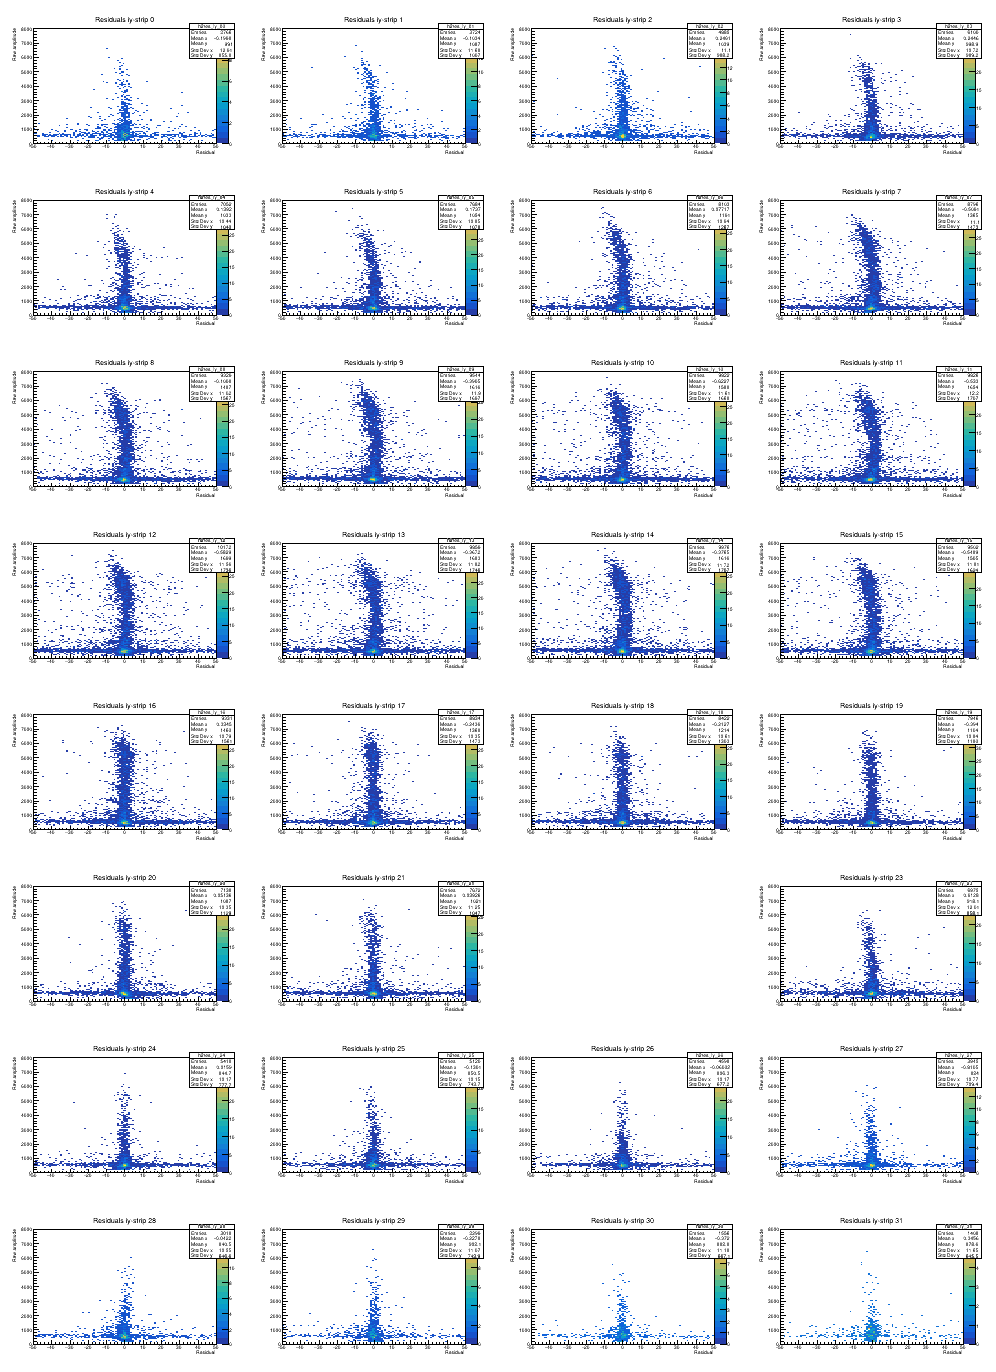

In [29]:
fit(0,31,0,31,"fity");
gResidualCanvas->Draw();

<h2>保存与读取参数</h2><p>文件前 32 行是 X，后 32 行是 Y，每行为 <code>strip b k</code>。无可用数据的条保持 k=0，后续跳过并报告；不能把恒等变换当成它的刻度。</p>

In [ ]:
%%cpp -d
    
void saveParameters(const char *fname="cal_dssd1.txt")
{
    ofstream fout(fname);
    for (int i = 0; i < 32; ++i)
        fout << i << " " << parx[i][0] << " " << parx[i][1] << endl;
    for (int i = 0; i < 32; ++i)
        fout << i << " " << pary[i][0] << " " << pary[i][1] << endl;
    fout.close();
}

void readParameters(const char *fname, double px[32][2], double py[32][2])
{
    ifstream fin(fname);
    int id;
    for (int i = 0; i < 32; ++i) fin >> id >> px[i][0] >> px[i][1];
    for (int i = 0; i < 32; ++i) fin >> id >> py[i][0] >> py[i][1];
    fin.close();
}

In [ ]:
saveParameters("cal_dssd1.txt");

<h2>检查整体归一结果</h2><p>重新计算全部候选的 $E_x^{(\rm rel)}$ 和 $E_y^{(\rm rel)}$，查看二维主条带及 $E_y^{(\rm rel)}-E_x^{(\rm rel)}$ 是否在零附近、是否随幅度发生漂移。整体主条带正确不替代逐条检查；少数错误系数可能被高统计条掩盖。</p>

In [ ]:
void calibrateAndPlot(const char* fname="cal_dssd1.txt")
{
    double px[32][2], py[32][2];
    readParameters(fname, px, py);

    DeleteIfExists("hxy_check");
    DeleteIfExists("hdiff_check");

    auto hxy = new TH2F("hxy_check", "Normalized front-back;X relative amplitude;Y relative amplitude", 400, 0, 8000, 400, 0, 8000);
    auto hdiff = new TH2F("hdiff_check", "Normalized residual;X relative amplitude;Y-X relative amplitude", 400, 0, 8000, 200, -200, 200);

    Long64_t skipped = 0;
    Long64_t nentries = tree->GetEntries();
    for (Long64_t jentry = 0; jentry < nentries; ++jentry) {
        tree->GetEntry(jentry);

        if (px[ix][1]<=0 || py[iy][1]<=0) { ++skipped; continue; }
        double cxe = px[ix][1] * xe + px[ix][0];
        double cye = py[iy][1] * ye + py[iy][0];

        hxy->Fill(cxe, cye);
        hdiff->Fill(cxe, cye - cxe);
    }

    DeleteIfExists("c_check");
    auto c_check = new TCanvas("c_check", "Global check", 1000, 430);
    c_check->Divide(2,1);
    c_check->cd(1); gPad->SetLeftMargin(0.14); gPad->SetRightMargin(0.16); hxy->SetStats(0); hxy->Draw("colz");
    c_check->cd(2); gPad->SetLeftMargin(0.14); gPad->SetRightMargin(0.16); hdiff->SetStats(0); hdiff->Draw("colz");
    c_check->Update();
    cout << "Input=" << nentries << ", calibrated=" << nentries-skipped
         << ", unavailable calibration=" << skipped << endl;
}

Input=210820, calibrated=210820, unavailable calibration=0

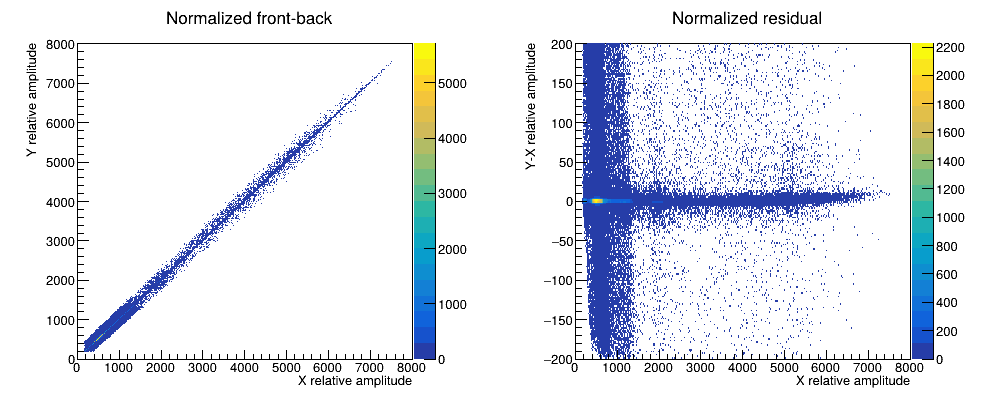

In [35]:
calibrateAndPlot("cal_dssd1.txt");
TCanvas *cCheck=(TCanvas*)gROOT->GetListOfCanvases()->FindObject("c_check");
cCheck->Draw();

<h3>Discussion: Limitations and the Multi-path Approach</h3><p>逐组传播容易实现，但前面步骤的参数误差会传到后面，各条也会共享参考误差。传播步数少不等于误差可以忽略。还可从不同参考路径检查参数稳定性，见<a href="3.5_DSSD_FB_correlation_II_DSSD1_multi-path.html">Multi-path calibration 与误差传播</a>。该补充展示候选参数的组合；共享数据或参考条时，应同时考虑路径间的 covariance。</p>

<h2 id="assignment">作业：三层 DSSD 的相对归一与 hit 列表</h2><p>参照三步方法求 DSSD1–3 的参数，检查各条 residual，保存参数。把 raw amplitude 转为相对幅度，选择幅度≥100 的条，分别按两面幅度从高到低排列，条号与幅度一起移动，写入新的 ROOT 文件。</p><pre><code class="language-cpp">Int_t x1hit, y1hit;
Int_t x1[32], y1[32];
Double_t x1e[32], y1e[32];
Double_t x1es, y1es;
Int_t x1m, y1m;</code></pre><p>branch 的 leaflist 使用 <code>x1[x1hit]/I</code>、<code>x1e[x1hit]/D</code> 等形式。<code>x1es,y1es</code> 是通过阈值的相对幅度之和；<code>x1m,y1m</code> 只统计相邻有效条的连通组数，不代表已确定的粒子数。DSSD2、3 使用同样结构，保留源事例编号。3.6 再根据两面能量关系判断如何合并或配对。</p>